# SBERT for Quora Question Pairs

In [17]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
%pip install -q lightning

In [19]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torchmetrics.functional.classification import (
    binary_accuracy,
    binary_precision,
    binary_recall,
    binary_f1_score,
)
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding
from datasets import load_dataset
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from tqdm import tqdm

In [20]:
DATASET_NAME = "AlekseyKorshuk/quora-question-pairs"
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
LOG_DIR = "drive/MyDrive/lms/nlp/assignment"
SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 2
D_MODEL = 384
LEARNING_RATE = 3e-5
MAX_EPOCHS = 3
PATIENCE = 10

## 1. Prepare dataset

In [21]:
ds = load_dataset(DATASET_NAME, split="train")

In [22]:
ds

Dataset({
    features: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'],
    num_rows: 404290
})

In [23]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [24]:
ds_cleaned = ds.filter(
    lambda row: isinstance(row["question1"], str) and isinstance(row["question2"], str)
)


def tokenize_row(row):
    output_1 = tokenizer(row["question1"], truncation=True)
    output_2 = tokenizer(row["question2"], truncation=True)
    return {
        "input_ids_1": output_1["input_ids"],
        "attention_mask_1": output_1["attention_mask"],
        "input_ids_2": output_2["input_ids"],
        "attention_mask_2": output_2["attention_mask"],
    }


ds_tokenized = ds_cleaned.map(
    lambda row: tokenize_row(row),
    batched=True,
    remove_columns=["qid1", "qid2", "question1", "question2"],
)

In [25]:
ds_split_1 = ds_tokenized.train_test_split(0.3)
ds_split_2 = ds_split_1["test"].train_test_split(0.5)
ds_train, ds_val, ds_test = ds_split_1["train"], ds_split_2["train"], ds_split_2["test"]

In [26]:
ds_train, ds_val, ds_test

(Dataset({
     features: ['id', 'is_duplicate', 'input_ids_1', 'attention_mask_1', 'input_ids_2', 'attention_mask_2'],
     num_rows: 283000
 }),
 Dataset({
     features: ['id', 'is_duplicate', 'input_ids_1', 'attention_mask_1', 'input_ids_2', 'attention_mask_2'],
     num_rows: 60643
 }),
 Dataset({
     features: ['id', 'is_duplicate', 'input_ids_1', 'attention_mask_1', 'input_ids_2', 'attention_mask_2'],
     num_rows: 60644
 }))

In [27]:
def data_collator(batch):
    data_dict = {}

    for field in ("input_ids_1", "input_ids_2"):
        field_data = [torch.tensor(sample[field]) for sample in batch]
        data_dict[field] = pad_sequence(
            field_data,
            batch_first=True,
            padding_value=tokenizer.pad_token_type_id,
        )

    for field in ("attention_mask_1", "attention_mask_2"):
        field_data = [torch.tensor(sample[field]) for sample in batch]
        data_dict[field] = pad_sequence(
            field_data,
            batch_first=True,
            padding_value=0,
        )

    data_dict["is_duplicate"] = torch.tensor([sample["is_duplicate"] for sample in batch])
    return data_dict

In [28]:
train_loader = DataLoader(
    ds_train,
    BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=data_collator,
)
val_loader = DataLoader(
    ds_val,
    BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=data_collator,
)
test_loader = DataLoader(
    ds_test,
    BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=data_collator,
)

## 2. Approach 1: Use pretrain

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [30]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1)
    return (last_hidden_state * mask).sum(1) / mask.sum(1)

In [ ]:
sbert = AutoModel.from_pretrained(MODEL_NAME).to(device)

In [36]:
def eval_sbert(dataloader):
    sim_scores = []
    labels = []
    print(f"Number of batches: {len(dataloader)}")

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids_1 = batch["input_ids_1"].to(device)
            attention_mask_1 = batch["attention_mask_1"].to(device)
            input_ids_2 = batch["input_ids_2"].to(device)
            attention_mask_2 = batch["attention_mask_2"].to(device)

            output_1 = sbert(input_ids_1, attention_mask_1)
            output_2 = sbert(input_ids_2, attention_mask_2)

            embed_1 = mean_pooling(output_1.last_hidden_state, attention_mask_1)
            embed_2 = mean_pooling(output_2.last_hidden_state, attention_mask_2)

            sim = F.cosine_similarity(embed_1, embed_2)
            sim_scores.append(sim)
            labels.append(batch["is_duplicate"])

    return torch.concat(sim_scores).cpu(), torch.concat(labels)


In [ ]:
sim_scores, labels = eval_sbert(test_loader)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Number of batches: 1896


100%|██████████| 1896/1896 [00:51<00:00, 36.78it/s]


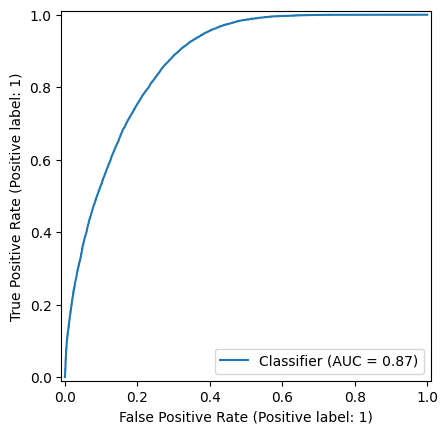

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, classification_report


RocCurveDisplay.from_predictions(labels, sim_scores)
plt.show()

Threshold taken from here: https://www.sbert.net/docs/package_reference/sentence_transformer/evaluation.html#:~:text=Similarity%3A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%2075.27%20%20(Threshold%3A-,0.7715,-)%0APrecision%20with

In [45]:
threshold = 0.7715
preds = sim_scores > threshold

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81     38432
           1       0.65      0.84      0.73     22212

    accuracy                           0.78     60644
   macro avg       0.77      0.79      0.77     60644
weighted avg       0.80      0.78      0.78     60644



## 3. Approach 2: Fine-tuning

### 3.1. Prepare model

In [ ]:
class SbertQuoraModel(L.LightningModule):
    def __init__(self, sbert, d_model=D_MODEL):
        super().__init__()
        self.sbert = sbert
        self.d_model = d_model
        self.classifier = nn.Linear(3 * d_model, 1)

    def mean_pooling(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1)
        return (last_hidden_state * mask).sum(1) / mask.sum(1)

    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        output_1 = self.sbert(input_ids_1, attention_mask_1)
        output_2 = self.sbert(input_ids_2, attention_mask_2)

        embed_1 = self.mean_pooling(output_1.last_hidden_state, attention_mask_1)
        embed_2 = self.mean_pooling(output_2.last_hidden_state, attention_mask_2)
        embed = torch.concat((embed_1, embed_2, torch.abs(embed_1 - embed_2)), dim=1)

        logits = self.classifier(embed).reshape(-1)
        return logits

    def training_step(self, batch, batch_idx):
        input_ids_1 = batch["input_ids_1"]
        attention_mask_1 = batch["attention_mask_1"]
        input_ids_2 = batch["input_ids_2"]
        attention_mask_2 = batch["attention_mask_2"]
        labels = batch["is_duplicate"].float()

        logits = self(input_ids_1, attention_mask_1, input_ids_2, attention_mask_2)
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        preds = logits > 0

        accuracy = binary_accuracy(preds, labels)
        precision = binary_precision(preds, labels)
        recall = binary_recall(preds, labels)
        f1 = binary_f1_score(preds, labels)

        self.log("train_loss", loss)
        self.log("train_accuracy", accuracy)
        self.log("train_precision", precision)
        self.log("train_recall", recall)
        self.log("train_f1", f1)

        return loss

    def validation_step(self, batch, batch_idx):
        input_ids_1 = batch["input_ids_1"]
        attention_mask_1 = batch["attention_mask_1"]
        input_ids_2 = batch["input_ids_2"]
        attention_mask_2 = batch["attention_mask_2"]
        labels = batch["is_duplicate"].float()

        logits = self(input_ids_1, attention_mask_1, input_ids_2, attention_mask_2)
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        preds = logits > 0

        accuracy = binary_accuracy(preds, labels)
        precision = binary_precision(preds, labels)
        recall = binary_recall(preds, labels)
        f1 = binary_f1_score(preds, labels)

        self.log("val_loss", loss)
        self.log("val_accuracy", accuracy)
        self.log("val_precision", precision)
        self.log("val_recall", recall)
        self.log("val_f1", f1)

    def test_step(self, batch, batch_idx):
        input_ids_1 = batch["input_ids_1"]
        attention_mask_1 = batch["attention_mask_1"]
        input_ids_2 = batch["input_ids_2"]
        attention_mask_2 = batch["attention_mask_2"]
        labels = batch["is_duplicate"].float()

        logits = self(input_ids_1, attention_mask_1, input_ids_2, attention_mask_2)
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        preds = logits > 0

        accuracy = binary_accuracy(preds, labels)
        precision = binary_precision(preds, labels)
        recall = binary_recall(preds, labels)
        f1 = binary_f1_score(preds, labels)

        self.log("test_loss", loss)
        self.log("test_accuracy", accuracy)
        self.log("test_precision", precision)
        self.log("test_recall", recall)
        self.log("test_f1", f1)

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), LEARNING_RATE)
        return optimizer

### 3.2. Train model

In [ ]:
sbert = AutoModel.from_pretrained(MODEL_NAME)
sbert.train()
model = SbertQuoraModel(sbert)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
trainer = L.Trainer(
    default_root_dir=LOG_DIR,
    enable_checkpointing=False,
    callbacks=[EarlyStopping("val_loss", patience=PATIENCE)],
    max_epochs=MAX_EPOCHS,
    val_check_interval=500,
    limit_val_batches=500
)
trainer.fit(model, train_loader, val_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ sbert      │ BertModel │ 22.7 M │ train │     0 │
│ 1 │ classifier │ Linear    │  1.2 K │ train │     0 │
└───┴────────────┴───────────┴────────┴───────┴───────┘

Trainable params: 22.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 22.7 M                                                                                               
Total estimated model params size (MB): 90.857                                                                     
Modules in train mode: 121                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


In [ ]:
trainer.test(dataloaders=test_loader)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.


ValueError: `.test(ckpt_path="best")` is set but `ModelCheckpoint` is not configured.